[OK] Using column 4 (corrected). Points: 2048. x range: 188.287–1104.683 nm; y max: 176901.107


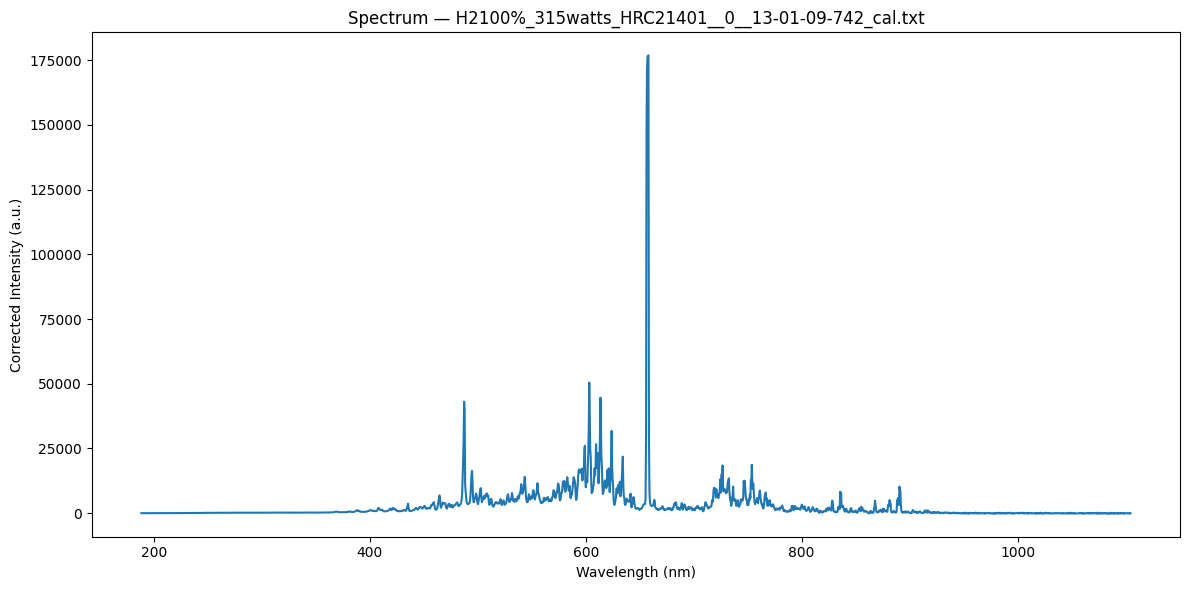

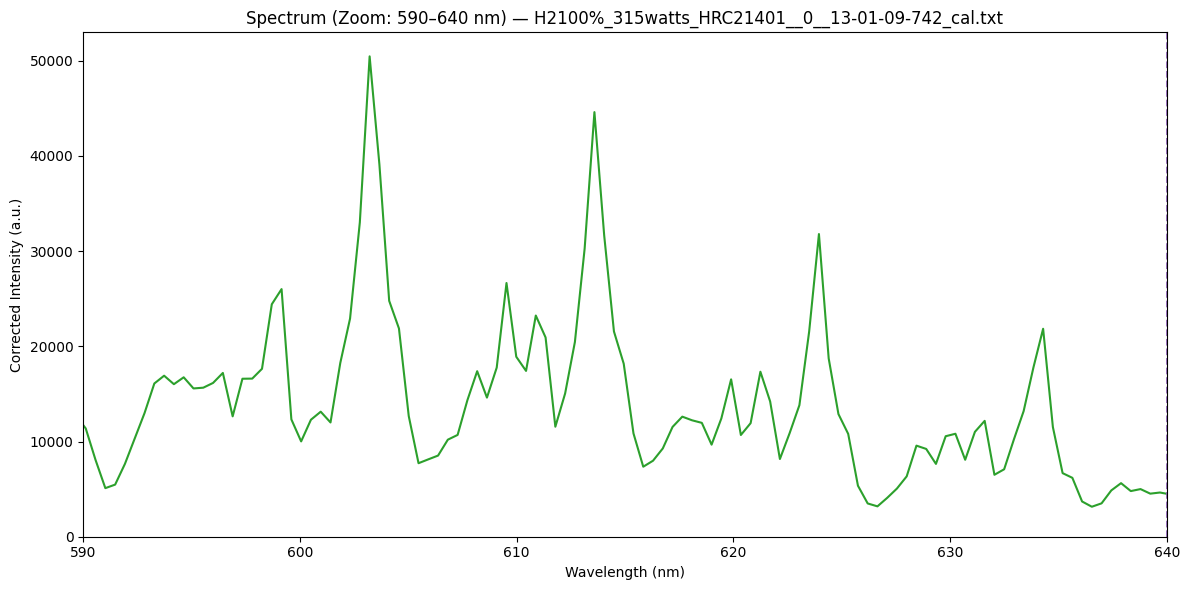

: 

In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox
import numpy as np
import matplotlib.pyplot as plt
import os

def read_x_corrected_col4(path):
    xs, ys = [], []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip().replace("\ufeff","").replace("−","-")
            if not s or s[0] in "#;/":  # skip blanks/comments
                continue
            parts = s.split(",")  # your file is comma-separated
            if len(parts) < 5:    # need columns 0 and 4
                continue
            try:
                x = float(parts[0])
                y = float(parts[4])  # corrected spectrum
            except ValueError:
                continue
            if np.isfinite(x) and np.isfinite(y):
                xs.append(x); ys.append(y)

    if not xs:
        raise ValueError("No valid numeric rows with columns 0 & 4 found.")
    x = np.asarray(xs, float)
    y = np.asarray(ys, float)

    # sort by wavelength (some instruments output out-of-order blocks)
    order = np.argsort(x)
    return x[order], y[order]

def plot_full(x, y, title):
    plt.figure(figsize=(12,6))
    plt.plot(x, y, lw=1.5, color="tab:blue")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Corrected Intensity (a.u.)")
    plt.title(f"Spectrum — {title}")
    plt.tight_layout(); plt.show()

def plot_zoom_590_640(x, y, title):
    plt.figure(figsize=(12,6))
    plt.plot(x, y, lw=1.5, color="tab:green")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Corrected Intensity (a.u.)")
    plt.title(f"Spectrum (Zoom: 590–640 nm) — {title}")
    plt.xlim(590, 640)
    m = (x >= 590) & (x <= 640)
    if np.any(m):
        ymax = float(np.max(y[m]))
        if np.isfinite(ymax) and ymax > 0:
            plt.ylim(0, ymax * 1.05)
    for v in (590, 640):
        plt.axvline(v, color="tab:purple", ls="--", lw=1.3)
    plt.tight_layout(); plt.show()

def main():
    root = tk.Tk(); root.withdraw()
    fname = filedialog.askopenfilename(
        title="Select corrected spectrum file",
        filetypes=[("Text/CSV", "*.txt *.csv"), ("All files", "*.*")]
    )
    if not fname:
        return

    try:
        x, y = read_x_corrected_col4(fname)
    except Exception as e:
        messagebox.showerror("Load error", f"{os.path.basename(fname)}\n{e}")
        return

    title = os.path.basename(fname)
    print(f"[OK] Using column 4 (corrected). Points: {len(x)}. "
          f"x range: {x.min():.3f}–{x.max():.3f} nm; y max: {y.max():.3f}")
    plot_full(x, y, title)
    plot_zoom_590_640(x, y, title)

if __name__ == "__main__":
    main()
